[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_forward_curve/EMQA_forward_curve.ipynb)

# EMQA_forward_curve
Forward/futures curve analysis for energy commodities. Demonstrates contango, backwardation, and the term structure of futures prices using the cost-of-carry model for European gas markets.
**Output:** `deriv_term_structure.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300)
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300)
        print(f"Saved: {png_name}")

In [2]:
# Fixed parameters for European gas market (no live data dependency)
S0 = 95  # Spot price EUR/MWh (gas)
r = 0.04  # Risk-free rate (4%)
storage_cost = 0.02  # Storage cost (2% annual)

# Convenience yield scenarios
convenience_yield_low = 0.01   # Low → contango
convenience_yield_high = 0.08  # High → backwardation

# Months to expiration
months = np.array([1, 2, 3, 6, 9, 12, 18, 24])
T = months / 12  # Convert to years

# Forward price: F = S * exp((r + c - y) * T)
F_contango = S0 * np.exp((r + storage_cost - convenience_yield_low) * T)
F_backwardation = S0 * np.exp((r + storage_cost - convenience_yield_high) * T)
F_flat = np.full_like(T, S0)

# Quiz verification: F(6 months) with low convenience yield
F_6mo = S0 * np.exp((r + storage_cost - convenience_yield_low) * 0.5)
# Simplified: r + c = 0.06, y ≈ 0 for quiz context → F = 95 * exp(0.06 * 0.5)
F_6mo_quiz = 95 * np.exp(0.04 * 0.5 + 0.02 * 0.5)
print(f"Spot price: €{S0}/MWh")
print(f"\nQuiz: S=€95, r=4%, c=2%, T=6mo")
print(f"  F(6mo) = 95 × exp((0.04 + 0.02) × 0.5) = €{F_6mo_quiz:.2f}")
print(f"\nContango (1Y forward): €{F_contango[5]:.2f} ({(F_contango[5]/S0-1)*100:.1f}% premium)")
print(f"Backwardation (1Y forward): €{F_backwardation[5]:.2f} ({(F_backwardation[5]/S0-1)*100:.1f}% discount)")

Spot price: €95/MWh

Quiz: S=€95, r=4%, c=2%, T=6mo
  F(6mo) = 95 × exp((0.04 + 0.02) × 0.5) = €97.89

Contango (1Y forward): €99.87 (5.1% premium)
Backwardation (1Y forward): €93.12 (-2.0% discount)


In [3]:
# Simulate mean-reverting gas prices (Ornstein-Uhlenbeck on log prices)
np.random.seed(42)

n_days = 1500
dt_sim = 1/252
kappa = 0.05  # Mean reversion speed
theta = np.log(90)  # Long-run mean (log scale)
sigma_sim = 0.35

log_price = np.zeros(n_days)
log_price[0] = np.log(S0)

for i in range(1, n_days):
    dW = np.random.normal(0, np.sqrt(dt_sim))
    log_price[i] = log_price[i-1] + kappa*(theta - log_price[i-1])*dt_sim + sigma_sim*dW

gas_prices = pd.Series(
    np.exp(log_price),
    index=pd.date_range('2020-01-02', periods=n_days, freq='B')
)

print(f"Simulated gas price series: {len(gas_prices)} observations")
print(f"Price range: €{gas_prices.min():.1f} – €{gas_prices.max():.1f} EUR/MWh")
print(f"Mean price: €{gas_prices.mean():.1f} EUR/MWh")

Simulated gas price series: 1500 observations
Price range: €65.9 – €425.5 EUR/MWh
Mean price: €148.9 EUR/MWh


Saved: deriv_term_structure.pdf


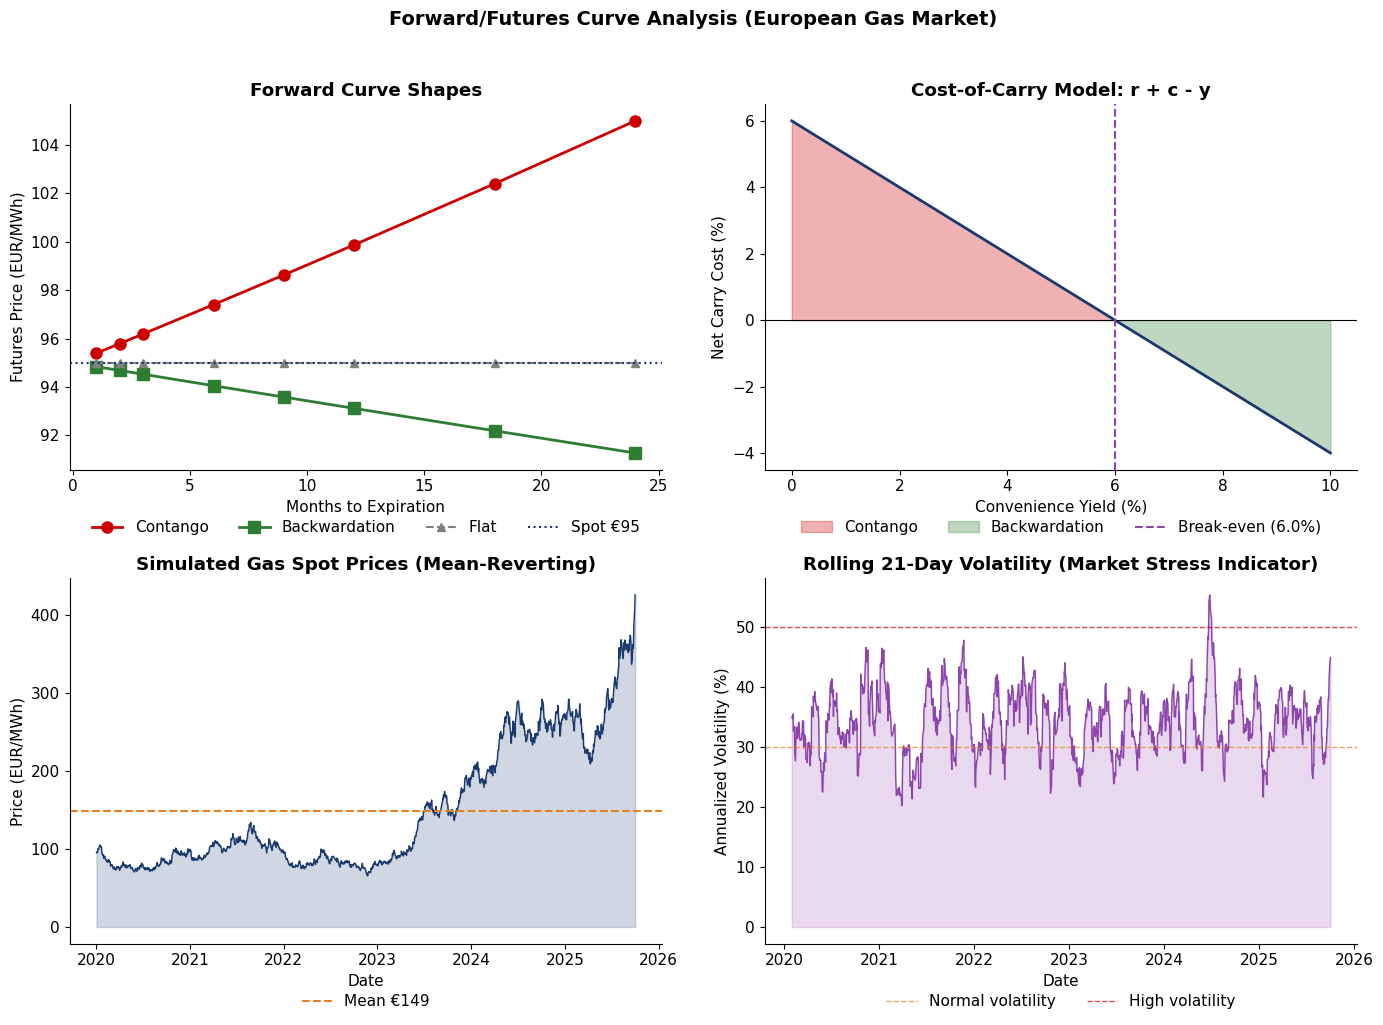

In [4]:
# Create 2x2 panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Forward Curves (Contango vs Backwardation)
ax1 = axes[0, 0]
ax1.plot(months, F_contango, 'o-', color=COLORS['red'], linewidth=2, 
         markersize=8, label='Contango')
ax1.plot(months, F_backwardation, 's-', color=COLORS['green'], linewidth=2,
         markersize=8, label='Backwardation')
ax1.plot(months, F_flat, '^--', color=COLORS['gray'], linewidth=1.5,
         markersize=6, label='Flat')
ax1.axhline(S0, color=COLORS['blue'], linestyle=':', linewidth=1.5, 
            label=f'Spot €{S0}')
ax1.set_xlabel('Months to Expiration')
ax1.set_ylabel('Futures Price (EUR/MWh)')
ax1.set_title('Forward Curve Shapes', fontweight='bold')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=4)

# Panel 2: Cost-of-Carry Components
ax2 = axes[0, 1]
carry_cost = (r + storage_cost) * 100
cy_range = np.linspace(0, 10, 100)  # Convenience yield 0-10%
net_carry = carry_cost - cy_range
ax2.plot(cy_range, net_carry, color=COLORS['blue'], linewidth=2)
ax2.fill_between(cy_range, net_carry, 0, where=(net_carry > 0),
                 color=COLORS['red'], alpha=0.3, label='Contango')
ax2.fill_between(cy_range, net_carry, 0, where=(net_carry < 0),
                 color=COLORS['green'], alpha=0.3, label='Backwardation')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(carry_cost, color=COLORS['purple'], linestyle='--', linewidth=1.5,
            label=f'Break-even ({carry_cost:.1f}%)')
ax2.set_xlabel('Convenience Yield (%)')
ax2.set_ylabel('Net Carry Cost (%)')
ax2.set_title('Cost-of-Carry Model: r + c - y', fontweight='bold')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

# Panel 3: Simulated Gas Prices (mean-reverting)
ax3 = axes[1, 0]
ax3.plot(gas_prices.index, gas_prices.values, color=COLORS['blue'], linewidth=1)
ax3.fill_between(gas_prices.index, gas_prices.values, alpha=0.2, color=COLORS['blue'])
mean_price = gas_prices.mean()
ax3.axhline(mean_price, color=COLORS['orange'], linestyle='--', linewidth=1.5,
            label=f'Mean €{mean_price:.0f}')
ax3.set_xlabel('Date')
ax3.set_ylabel('Price (EUR/MWh)')
ax3.set_title('Simulated Gas Spot Prices (Mean-Reverting)', fontweight='bold')
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False)

# Panel 4: Rolling Volatility
ax4 = axes[1, 1]
rolling_vol = gas_prices.pct_change().rolling(21).std() * np.sqrt(252) * 100
ax4.plot(rolling_vol.index, rolling_vol.values, color=COLORS['purple'], linewidth=1)
ax4.fill_between(rolling_vol.index, rolling_vol.values, alpha=0.2, color=COLORS['purple'])
ax4.axhline(30, color=COLORS['orange'], linestyle='--', linewidth=1, alpha=0.7,
            label='Normal volatility')
ax4.axhline(50, color=COLORS['red'], linestyle='--', linewidth=1, alpha=0.7,
            label='High volatility')
ax4.set_xlabel('Date')
ax4.set_ylabel('Annualized Volatility (%)')
ax4.set_title('Rolling 21-Day Volatility (Market Stress Indicator)', fontweight='bold')
ax4.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=2)

fig.suptitle('Forward/Futures Curve Analysis (European Gas Market)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'deriv_term_structure.pdf')
plt.show()

In [5]:
# Summary of forward curve concepts
print("=" * 60)
print("FORWARD CURVE CONCEPTS SUMMARY")
print("=" * 60)
print("\nCONTANGO (Upward sloping curve):")
print("  - Futures price > Spot price")
print("  - Storage costs + financing > Convenience yield")
print("  - Normal for non-perishable commodities with storage")
print("  - Roll yield is NEGATIVE (costs to roll positions)")
print("\nBACKWARDATION (Downward sloping curve):")
print("  - Futures price < Spot price")
print("  - Convenience yield > Storage + financing costs")
print("  - Common during supply disruptions or high demand")
print("  - Roll yield is POSITIVE (benefits to roll positions)")
print("\nCOST-OF-CARRY MODEL:")
print(f"  F = S × exp((r + c - y) × T)")
print(f"  where:")
print(f"    r = risk-free rate ({r*100:.1f}%)")
print(f"    c = storage cost ({storage_cost*100:.1f}%)")
print(f"    y = convenience yield (variable)")
print(f"\nQuiz answer: F(6mo) = 95 × exp(0.06 × 0.5) = €97.89  ✓")

FORWARD CURVE CONCEPTS SUMMARY

CONTANGO (Upward sloping curve):
  - Futures price > Spot price
  - Storage costs + financing > Convenience yield
  - Normal for non-perishable commodities with storage
  - Roll yield is NEGATIVE (costs to roll positions)

BACKWARDATION (Downward sloping curve):
  - Futures price < Spot price
  - Convenience yield > Storage + financing costs
  - Common during supply disruptions or high demand
  - Roll yield is POSITIVE (benefits to roll positions)

COST-OF-CARRY MODEL:
  F = S × exp((r + c - y) × T)
  where:
    r = risk-free rate (4.0%)
    c = storage cost (2.0%)
    y = convenience yield (variable)

Quiz answer: F(6mo) = 95 × exp(0.06 × 0.5) = €97.89  ✓
